# Introduction to Forecasting — Workshop Notebook

Welcome! This notebook accompanies the **Introduction to Forecasting** lecture slides.

**By the end of this notebook you will:**
- Understand 5 different forecasting methods and the equations behind them
- See that **no single method works best for all types of data**
- Learn how to measure forecast quality with error metrics
- Spot common traps (like forecasts that "look good" but are actually useless)

**How to use this notebook:**
1. Click **Runtime → Run all** to run every cell in order, OR
2. Step through one cell at a time using the play button on each cell

You do **not** need to write any code. At certain points you will see **"Try It!"** sections where you can change a single number and re-run the cell to experiment.

## Setup

Run the cell below to install and import everything we need. You only need to do this once.

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SETUP — Just run this cell, do not change anything      ║
# ╚══════════════════════════════════════════════════════════╝

# Install packages (these are already on Colab, but just in case)
!pip install -q numpy pandas matplotlib seaborn scikit-learn statsmodels

import warnings
warnings.filterwarnings("ignore")  # Hide technical warnings to keep output clean

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

# How many days we hold back for testing (about 7.5 weeks)
TEST_SIZE = 53


def plot_timeseries(df, title="Time Series Plot of Demand"):
    """Plot a time series of demand."""
    df_plot = df.copy()
    df_plot["date"] = pd.to_datetime(df_plot["date"])
    df_plot = df_plot.set_index("date")

    plt.figure(figsize=(15, 6))
    sns.lineplot(data=df_plot, x=df_plot.index, y="demand")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.ylim(bottom=0)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

---
## Section 1: The Data — Three Types of Demand

To prove that no single forecasting method is best, we need to test them on **different types of data**. We will generate three synthetic demand datasets, each with very different characteristics.

Why synthetic data? Because we control exactly what patterns are in the data, so we can understand *why* a method succeeds or fails.

### 1A: Intermittent Demand

**What is it?** Most days have zero demand, with occasional unpredictable spikes.

**Real-world example:** Spare parts for heavy machinery — nobody needs one for weeks, then suddenly someone orders 15.

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  FUNCTION DEFINITION — Just run this cell, do not change ║
# ╚══════════════════════════════════════════════════════════╝

def generate_intermittent_demand():
    np.random.seed(42)
    dates = pd.date_range(start="2025-01-01", end="2025-12-31", freq="D")

    prob_demand = 0.25   # 25% chance of demand on any given day
    max_demand = 20

    demand = [
        np.random.randint(1, max_demand + 1) if np.random.rand() < prob_demand else 0
        for _ in range(len(dates))
    ]

    return pd.DataFrame({"date": dates, "product_id": "SKU_001", "demand": demand})

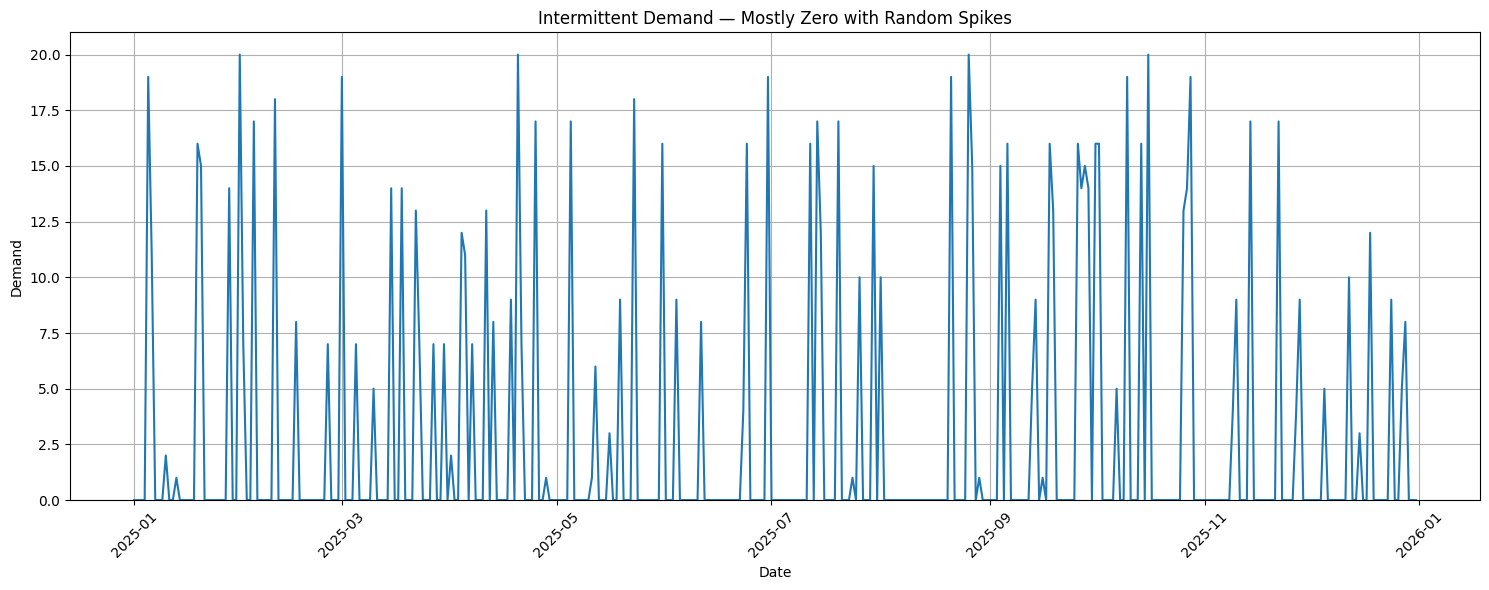

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  PLOT — Just run this cell, do not change anything        ║
# ╚══════════════════════════════════════════════════════════╝

intermittent_demand = generate_intermittent_demand()
plot_timeseries(intermittent_demand, title="Intermittent Demand — Mostly Zero with Random Spikes")

### 1B: Seasonal Demand

**What is it?** Demand follows a repeating calendar-driven pattern — higher in some months, lower in others.

**Real-world example:** Ice cream sales (peak in summer), or gift shops (peak in December).

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  FUNCTION DEFINITION — Just run this cell, do not change ║
# ╚══════════════════════════════════════════════════════════╝

def generate_seasonal_demand():
    np.random.seed(42)
    dates = pd.date_range(start="2025-01-01", end="2025-12-31", freq="D")
    base_demand = 20

    monthly_factors = {
        1: 0.8,  2: 0.9,  3: 1.0,  4: 1.1,
        5: 1.2,  6: 1.3,  7: 1.4,  8: 1.3,
        9: 1.1, 10: 1.0, 11: 1.2, 12: 1.5,
    }

    demand = []
    for date in dates:
        daily = base_demand * monthly_factors[date.month]
        noisy = np.random.normal(loc=daily, scale=1)
        demand.append(max(0, round(noisy)))

    return pd.DataFrame({"date": dates, "product_id": "SKU_001", "demand": demand})

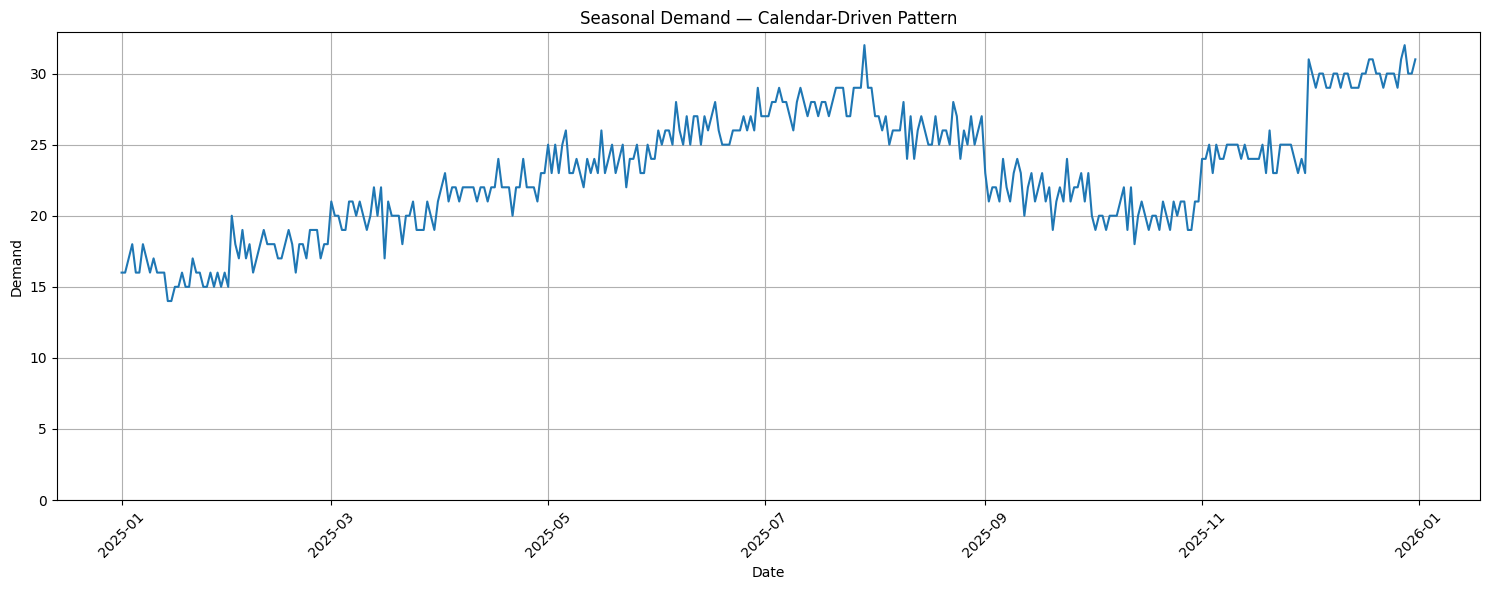

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  PLOT — Just run this cell, do not change anything        ║
# ╚══════════════════════════════════════════════════════════╝

seasonal_demand = generate_seasonal_demand()
plot_timeseries(seasonal_demand, title="Seasonal Demand — Calendar-Driven Pattern")

### 1C: Smooth (Stationary) Demand

**What is it?** Demand hovers around a stable average with only small random fluctuations. No trend, no seasonality.

**Real-world example:** Everyday staples like bread or toilet paper.

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  FUNCTION DEFINITION — Just run this cell, do not change ║
# ╚══════════════════════════════════════════════════════════╝

def generate_smooth_demand():
    np.random.seed(42)
    dates = pd.date_range(start="2025-01-01", end="2025-12-31", freq="D")
    base_demand = 20

    demand = []
    for date in dates:
        noisy = np.random.normal(loc=base_demand, scale=1)
        demand.append(max(0, round(noisy)))

    return pd.DataFrame({"date": dates, "product_id": "SKU_001", "demand": demand})

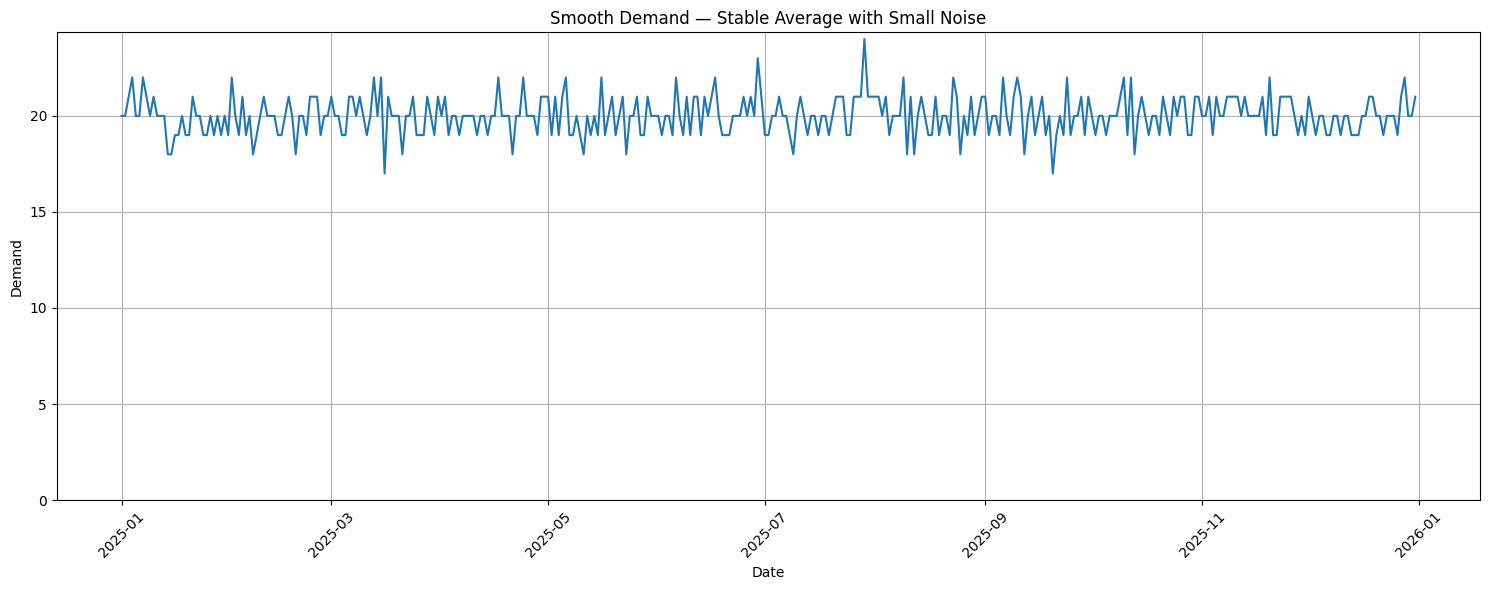

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  PLOT — Just run this cell, do not change anything        ║
# ╚══════════════════════════════════════════════════════════╝

smooth_demand = generate_smooth_demand()
plot_timeseries(smooth_demand, title="Smooth Demand — Stable Average with Small Noise")

---
## Section 2: How Do We Know If a Forecast Is Good?

### Train/Test Split

Think of it like studying for an exam:
- **Training data** = the textbook you study from
- **Test data** = the exam questions you have never seen before

We train our model on historical data, then test it on the most recent days that the model has **never seen**.

```
[========== Training Data (312 days) ==========|==== Test Data (53 days) ====]
                  Model learns from this  →  →     We measure accuracy here
```

In this notebook we hold back the last **53 days** (~7.5 weeks) as our test set.

### Error Metrics

We use three metrics to measure how far off our forecasts are. **Lower is better for all three.**

| Metric | What it means | Formula |
|--------|--------------|---------|
| **MAE** (Mean Absolute Error) | On average, how many units is the forecast off by? | $\text{MAE} = \frac{1}{n}\sum\|y_i - \hat{y}_i\|$ |
| **RMSE** (Root Mean Squared Error) | Like MAE, but penalises big errors more heavily. | $\text{RMSE} = \sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ |
| **MAPE** (Mean Absolute Percentage Error) | The average percentage the forecast is off by. | $\text{MAPE} = \frac{1}{n}\sum\left\|\frac{y_i - \hat{y}_i}{y_i}\right\|$ |

**Warning about MAPE:** When actual demand is **zero** (common in intermittent data), MAPE divides by zero and produces nonsensical numbers. Keep this in mind later!

---
## Section 3: Walk-Forward Validation

In real life, you never have tomorrow's data today. Our testing process mimics this:

1. Train the model on all data up to today
2. Forecast **one day ahead**
3. Reveal the actual value for that day
4. Add it to the training data
5. Repeat for the next day

This is called **walk-forward validation**. Every forecast function in this notebook uses this approach.

All forecasting functions below follow the same pattern:
- Split data into train/test
- Loop through each test day, forecast one step, then reveal the truth
- Print error metrics (MAE, RMSE, MAPE)
- Plot the training data, actual test data, and forecasted values

---
## Section 4: Forecasting Methods

We will now go through **5 forecasting methods**, from simplest to most complex. For each one we explain the equation, run it, and give you a chance to experiment.

---

### 4A: Naive Forecast

**The idea:** Tomorrow's forecast = today's actual value. That's it.

$$\hat{y}_{t+1} = y_t$$

This is the **simplest possible forecast** and serves as our **baseline**. Any useful method should beat it.

There are **no parameters to tune** — that's the whole point. As we go through the other methods, you will see that some of them *secretly become naive* when you set their parameters to certain values.

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  FUNCTION DEFINITION — Just run this cell, do not change ║
# ╚══════════════════════════════════════════════════════════╝

def naive_forecast(df, plot=True):
    train = df.iloc[:-TEST_SIZE].copy()
    test = df.iloc[-TEST_SIZE:].copy()
    history = train["demand"].tolist()
    predictions = []

    for t in range(len(test)):
        yhat = history[-1]  # Tomorrow = today
        predictions.append(yhat)
        history.append(test["demand"].iloc[t])

    test = test.copy()
    test["forecast"] = predictions

    mae = mean_absolute_error(test["demand"], test["forecast"])
    rmse = np.sqrt(mean_squared_error(test["demand"], test["forecast"]))
    mape = mean_absolute_percentage_error(test["demand"], test["forecast"])

    metrics = {"MAE": round(mae, 2), "RMSE": round(rmse, 2), "MAPE": round(mape, 4)}
    print(f"MAE: {metrics['MAE']}  |  RMSE: {metrics['RMSE']}  |  MAPE: {metrics['MAPE']}")

    if plot:
        plt.figure(figsize=(14, 6))
        plt.plot(train.index, train["demand"], label="Train")
        plt.plot(test.index, test["demand"], label="Actual (Test)")
        plt.plot(test.index, test["forecast"], label="Forecast", linestyle="--")
        plt.ylim(bottom=0)
        plt.legend()
        plt.title("Naive Forecast")
        plt.show()

    return test, metrics

MAE: 3.74  |  RMSE: 6.47  |  MAPE: 8412384209616587.0


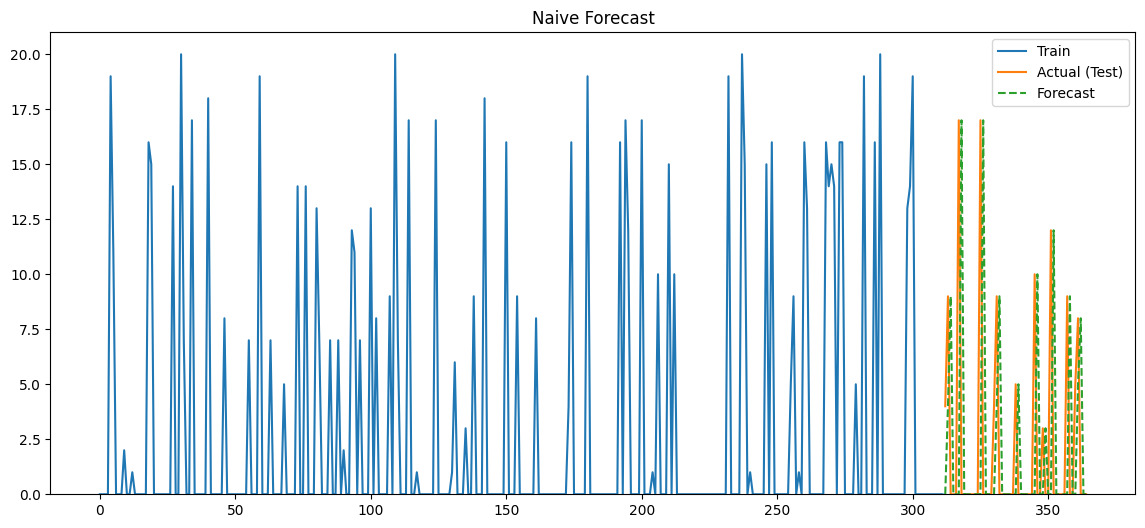

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  RUN FORECAST — Just run this cell, do not change         ║
# ╚══════════════════════════════════════════════════════════╝

naive_test, naive_metrics = naive_forecast(intermittent_demand)

---
### 4B: Moving Average

**The idea:** Average the last *k* days to forecast tomorrow.

$$\hat{y}_{t+1} = \frac{1}{k}\sum_{i=t-k+1}^{t} y_i$$

The **window** parameter (*k*) controls how many past days to include:
- **Small window** (e.g. 3) → forecast reacts quickly to recent changes, but is noisy
- **Large window** (e.g. 30) → forecast is smooth, but slow to react to shifts

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  FUNCTION DEFINITION — Just run this cell, do not change ║
# ╚══════════════════════════════════════════════════════════╝

def moving_average_forecast(df, window=7, plot=True):
    train = df.iloc[:-TEST_SIZE].copy()
    test = df.iloc[-TEST_SIZE:].copy()
    history = train["demand"].tolist()
    predictions = []

    for t in range(len(test)):
        yhat = np.mean(history[-window:])  # Average of last 'window' days
        predictions.append(yhat)
        history.append(test["demand"].iloc[t])

    test = test.copy()
    test["forecast"] = predictions

    mae = mean_absolute_error(test["demand"], test["forecast"])
    rmse = np.sqrt(mean_squared_error(test["demand"], test["forecast"]))
    mape = mean_absolute_percentage_error(test["demand"], test["forecast"])

    metrics = {"MAE": round(mae, 2), "RMSE": round(rmse, 2), "MAPE": round(mape, 4)}
    print(f"MAE: {metrics['MAE']}  |  RMSE: {metrics['RMSE']}  |  MAPE: {metrics['MAPE']}")

    if plot:
        plt.figure(figsize=(14, 6))
        plt.plot(train.index, train["demand"], label="Train")
        plt.plot(test.index, test["demand"], label="Actual (Test)")
        plt.plot(test.index, test["forecast"], label=f"Forecast (window={window})", linestyle="--")
        plt.ylim(bottom=0)
        plt.legend()
        plt.title(f"Moving Average Forecast (window={window})")
        plt.show()

    return test, metrics

MAE: 3.42  |  RMSE: 4.72  |  MAPE: 7404840357671164.0


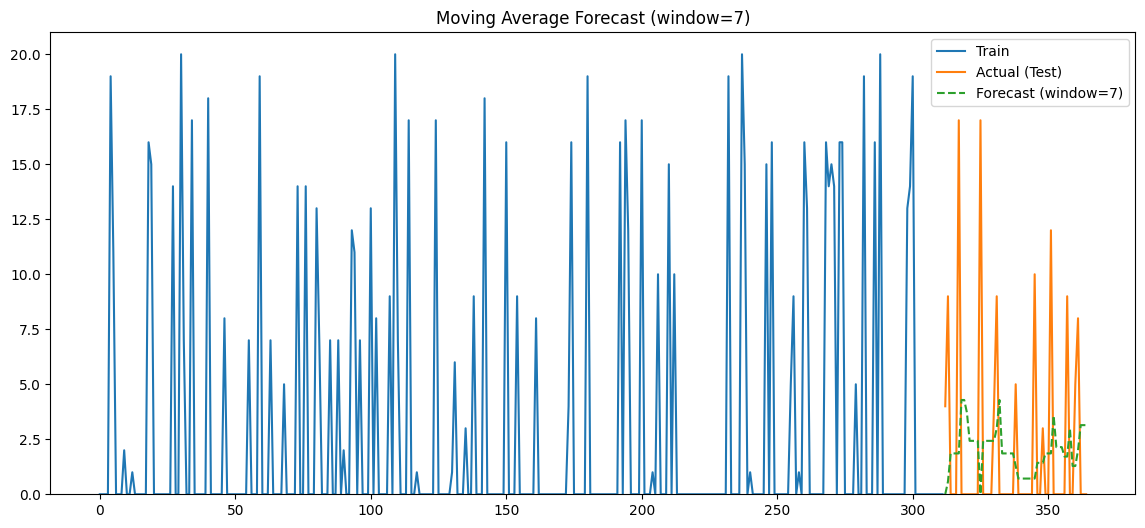

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  RUN FORECAST — Just run this cell, do not change         ║
# ╚══════════════════════════════════════════════════════════╝

ma_test, ma_metrics = moving_average_forecast(intermittent_demand, window=7)

### Try It!

In the cell below, change the `window` value and re-run to see how it affects the forecast. Try these:

- `window=1` — Only looks at yesterday. **Compare the MAE to the Naive forecast above — they should be identical!** A window of 1 means "tomorrow = today", which is exactly what Naive does.
- `window=3` — Averages the last 3 days. Slightly smoother.
- `window=14` — Averages 2 weeks. Much smoother.
- `window=30` — A full month. Very smooth — but can it keep up with sudden changes?

**What to look for:** How do the error metrics change as you increase the window?

In [ ]:
#  ╔══════════════════════════════════════════════╗
#  ║  CHANGE the number below and re-run this cell ║
#  ╚══════════════════════════════════════════════╝

moving_average_forecast(intermittent_demand, window=7)  # <-- CHANGE this number

**What did you learn?** A window of 1 is identical to the Naive forecast. Larger windows produce smoother forecasts but react more slowly to changes. There is no single "best" window — it depends on the data.

---
### 4C: Simple Exponential Smoothing

**The idea:** A weighted average of all past observations, where **recent data gets more weight**.

$$\hat{y}_{t+1} = \alpha \cdot y_t + (1 - \alpha) \cdot \hat{y}_t$$

The **alpha** parameter (between 0 and 1) controls how much we trust recent data:
- **High alpha** (e.g. 0.9) → trust today's value heavily, react fast
- **Low alpha** (e.g. 0.1) → trust the long-run average, very smooth forecast

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  FUNCTION DEFINITION — Just run this cell, do not change ║
# ╚══════════════════════════════════════════════════════════╝

def exp_smoothing_forecast(df, alpha=0.3, plot=True):
    train = df.iloc[:-TEST_SIZE].copy()
    test = df.iloc[-TEST_SIZE:].copy()
    history = train["demand"].tolist()
    predictions = []

    for t in range(len(test)):
        model = SimpleExpSmoothing(history).fit(smoothing_level=alpha, optimized=False)
        yhat = model.forecast(1)[0]
        predictions.append(yhat)
        history.append(test["demand"].iloc[t])

    test = test.copy()
    test["forecast"] = predictions

    mae = mean_absolute_error(test["demand"], test["forecast"])
    rmse = np.sqrt(mean_squared_error(test["demand"], test["forecast"]))
    mape = mean_absolute_percentage_error(test["demand"], test["forecast"])

    metrics = {"MAE": round(mae, 2), "RMSE": round(rmse, 2), "MAPE": round(mape, 4)}
    print(f"MAE: {metrics['MAE']}  |  RMSE: {metrics['RMSE']}  |  MAPE: {metrics['MAPE']}")

    if plot:
        plt.figure(figsize=(14, 6))
        plt.plot(train.index, train["demand"], label="Train")
        plt.plot(test.index, test["demand"], label="Actual (Test)")
        plt.plot(test.index, test["forecast"], label=f"Forecast (alpha={alpha})", linestyle="--")
        plt.ylim(bottom=0)
        plt.legend()
        plt.title(f"Simple Exponential Smoothing (alpha={alpha})")
        plt.show()

    return test, metrics

MAE: 3.59  |  RMSE: 4.93  |  MAPE: 7906384497012067.0


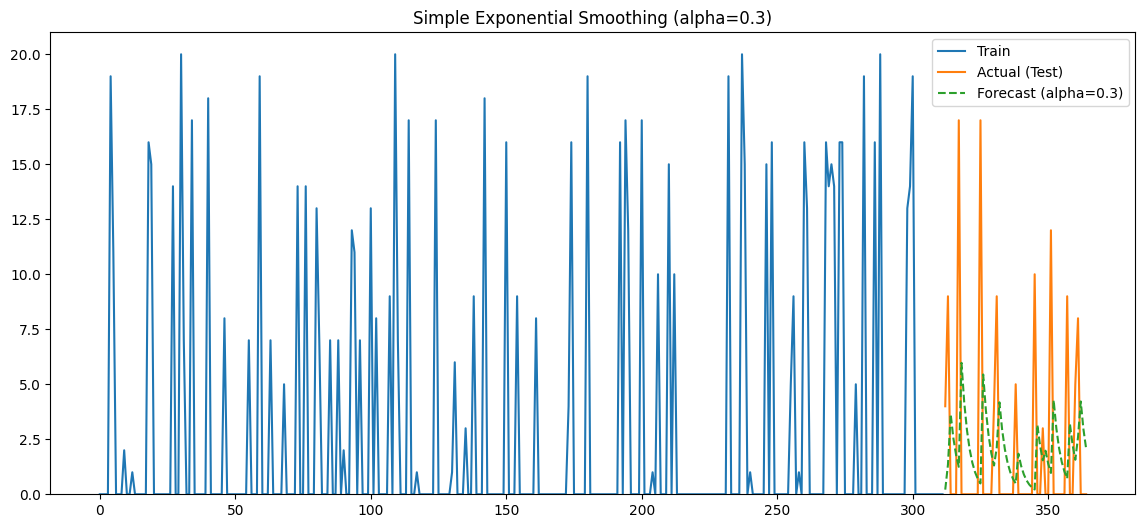

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  RUN FORECAST — Just run this cell, do not change         ║
# ╚══════════════════════════════════════════════════════════╝

es_test, es_metrics = exp_smoothing_forecast(intermittent_demand, alpha=0.3)

### Try It!

In the cell below, change the `alpha` value (must be between 0 and 1) and re-run. Try these:

- `alpha=0.1` — Trusts the long-run average heavily. Very smooth forecast.
- `alpha=0.5` — Balanced: equal weight to recent and historical.
- `alpha=0.9` — Trusts today's value almost entirely. Very reactive.
- `alpha=1.0` — **The formula becomes** $\hat{y}_{t+1} = 1.0 \times y_t + 0.0 \times \hat{y}_t = y_t$. **That's the Naive forecast again!** Compare the MAE — it should match exactly.

**What to look for:** How do the metrics change? At what point does it become "basically naive"?

MAE: 3.59  |  RMSE: 4.93  |  MAPE: 7906384497012067.0


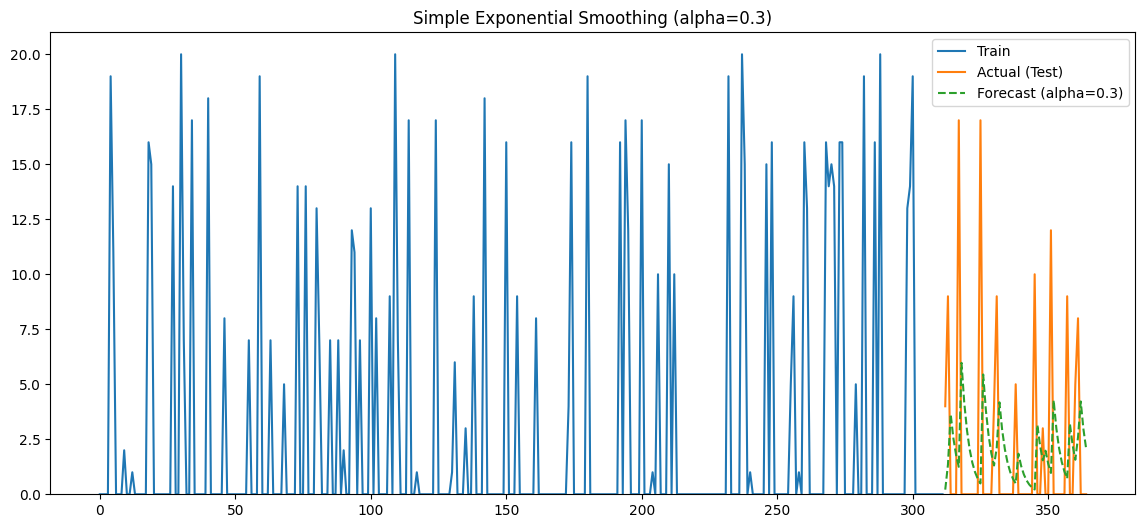

(          date product_id  demand  forecast
 312 2025-11-09    SKU_001       4  0.211136
 313 2025-11-10    SKU_001       9  1.347795
 314 2025-11-11    SKU_001       0  3.643457
 315 2025-11-12    SKU_001       0  2.550420
 316 2025-11-13    SKU_001       0  1.785294
 317 2025-11-14    SKU_001      17  1.249706
 318 2025-11-15    SKU_001       0  5.974794
 319 2025-11-16    SKU_001       0  4.182356
 320 2025-11-17    SKU_001       0  2.927649
 321 2025-11-18    SKU_001       0  2.049354
 322 2025-11-19    SKU_001       0  1.434548
 323 2025-11-20    SKU_001       0  1.004184
 324 2025-11-21    SKU_001       0  0.702929
 325 2025-11-22    SKU_001      17  0.492050
 326 2025-11-23    SKU_001       0  5.444435
 327 2025-11-24    SKU_001       0  3.811104
 328 2025-11-25    SKU_001       0  2.667773
 329 2025-11-26    SKU_001       0  1.867441
 330 2025-11-27    SKU_001       4  1.307209
 331 2025-11-28    SKU_001       9  2.115046
 332 2025-11-29    SKU_001       0  4.180532
 333 2025-

In [ ]:
#  ╔══════════════════════════════════════════════════════════════╗
#  ║  CHANGE the number below (between 0 and 1) and re-run       ║
#  ╚══════════════════════════════════════════════════════════════╝

exp_smoothing_forecast(intermittent_demand, alpha=0.3)  # <-- CHANGE this number

**What did you learn?** Alpha = 1 collapses Exponential Smoothing into the Naive method. Alpha = 0.1 gives heavy smoothing. The "best" alpha depends on whether your data has real signal in recent values or is mostly noise.

---
### 4D: The "Looks Good" Illusion

Look at the Naive forecast plot (or the alpha=1 / window=1 plots). The dashed forecast line seems to track the actual demand almost perfectly. It **looks** like a great forecast!

**But it is an illusion.**

The forecast is simply **copying yesterday's value, shifted forward by one day**:
- If demand jumps from 0 to 15 today, the forecast only says 15 *tomorrow* — one day too late
- It is not predicting anything — it is just **echoing the past**

**Rule of thumb: When a forecast line hugs the actuals almost perfectly, be suspicious.**

The scatter plot below proves this. We plot each forecast value against the *previous day's actual*. If the forecast is just a shifted copy, the points will form a **perfect diagonal line**.

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  FUNCTION + PLOT — Just run this cell, do not change      ║
# ╚══════════════════════════════════════════════════════════╝

def plot_shift_illusion(test_df):
    """Show that a forecast is just copying the previous day's value."""
    actual = test_df["demand"].values
    forecast = test_df["forecast"].values

    # forecast[t] vs actual[t-1] — if it's a shifted copy, these are equal
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: time series overlay
    axes[0].plot(test_df.index, actual, label="Actual", linewidth=1.5)
    axes[0].plot(test_df.index, forecast, label="Forecast", linestyle="--", linewidth=1.5)
    axes[0].set_title("Forecast vs Actual — Looks Great?")
    axes[0].set_ylabel("Demand")
    axes[0].legend()
    axes[0].set_ylim(bottom=0)

    # Right: scatter of forecast[t] vs actual[t-1]
    axes[1].scatter(actual[:-1], forecast[1:], alpha=0.6, edgecolors="k", linewidth=0.5)
    max_val = max(actual.max(), forecast.max()) + 1
    axes[1].plot([0, max_val], [0, max_val], "r--", label="Perfect copy line")
    axes[1].set_xlabel("Yesterday's Actual Demand")
    axes[1].set_ylabel("Today's Forecast")
    axes[1].set_title("Forecast[t] vs Actual[t-1] — It's Just a Shifted Copy!")
    axes[1].legend()
    axes[1].set_xlim(left=0)
    axes[1].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

# Use the naive forecast results from earlier
plot_shift_illusion(naive_test)

---
### 4E: Holt-Winters (Triple Exponential Smoothing)

**The idea:** Exponential Smoothing + **Trend** + **Seasonality**. Three components working together:

| Component | What it captures |
|-----------|-----------------|
| **Level** | The current average demand |
| **Trend** | Is demand going up or down over time? |
| **Seasonality** | Is there a repeating pattern (weekly, monthly, yearly)? |

**Parameters you can change:**
- `trend` — `"add"` (look for a trend) or `None` (assume no trend)
- `seasonal` — `"add"` (look for seasonality) or `None` (assume no seasonality)
- `seasonal_periods` — How many time steps in one full cycle (e.g. 7 for weekly, 30 for monthly, 52 for yearly)

**Important:** This method needs enough historical data to learn the seasonal pattern — at least 2 full cycles.

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  FUNCTION DEFINITION — Just run this cell, do not change ║
# ╚══════════════════════════════════════════════════════════╝

def holt_winters_forecast(df, seasonal_periods=52, trend="add", seasonal="add", plot=True):
    train = df.iloc[:-TEST_SIZE].copy()
    test = df.iloc[-TEST_SIZE:].copy()
    history = train["demand"].tolist()
    predictions = []

    for t in range(len(test)):
        try:
            model = ExponentialSmoothing(
                history,
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=seasonal_periods,
            )
            model_fit = model.fit()
            yhat = model_fit.forecast(1)[0]
        except Exception:
            yhat = np.mean(history[-7:])  # Fallback to simple average if model fails
        predictions.append(yhat)
        history.append(test["demand"].iloc[t])

    test = test.copy()
    test["forecast"] = predictions

    mae = mean_absolute_error(test["demand"], test["forecast"])
    rmse = np.sqrt(mean_squared_error(test["demand"], test["forecast"]))
    mape = mean_absolute_percentage_error(test["demand"], test["forecast"])

    metrics = {"MAE": round(mae, 2), "RMSE": round(rmse, 2), "MAPE": round(mape, 4)}
    print(f"MAE: {metrics['MAE']}  |  RMSE: {metrics['RMSE']}  |  MAPE: {metrics['MAPE']}")

    if plot:
        plt.figure(figsize=(14, 6))
        plt.plot(train.index, train["demand"], label="Train")
        plt.plot(test.index, test["demand"], label="Actual (Test)")
        plt.plot(test.index, test["forecast"], label="Forecast", linestyle="--")
        plt.ylim(bottom=0)
        plt.legend()
        plt.title(f"Holt-Winters Forecast (trend={trend}, seasonal={seasonal}, periods={seasonal_periods})")
        plt.show()

    return test, metrics

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  RUN FORECAST — Just run this cell, do not change         ║
# ╚══════════════════════════════════════════════════════════╝

hw_test, hw_metrics = holt_winters_forecast(intermittent_demand)

Holt-Winters may have struggled here — that is expected! Intermittent demand has no smooth seasonal pattern for it to learn. We will see it perform much better on seasonal data later in the Grand Comparison.

### Try It!

**Note: this cell takes 10-20 seconds to run — just wait for it to finish.**

In the cell below, you can change **three settings**. Change one at a time and re-run to see what happens:

- **`trend`** — Controls whether the model looks for an upward/downward trend.
  - `"add"` = yes, look for a trend (default)
  - `None` = no, assume demand is flat over time

- **`seasonal`** — Controls whether the model looks for a repeating pattern.
  - `"add"` = yes, look for seasonality (default)
  - `None` = no, assume no repeating pattern

- **`seasonal_periods`** — How many time steps make one full seasonal cycle.
  - `7` = weekly cycle
  - `30` = monthly cycle
  - `52` = roughly yearly cycle (default)

You can also change the **dataset**. Try `seasonal_demand` or `smooth_demand` instead!

**What to look for:** Try setting `seasonal=None` — does it still struggle? Try running on `seasonal_demand` — does it improve?

MAE: 3.84  |  RMSE: 4.99  |  MAPE: 1.0904395154145272e+16


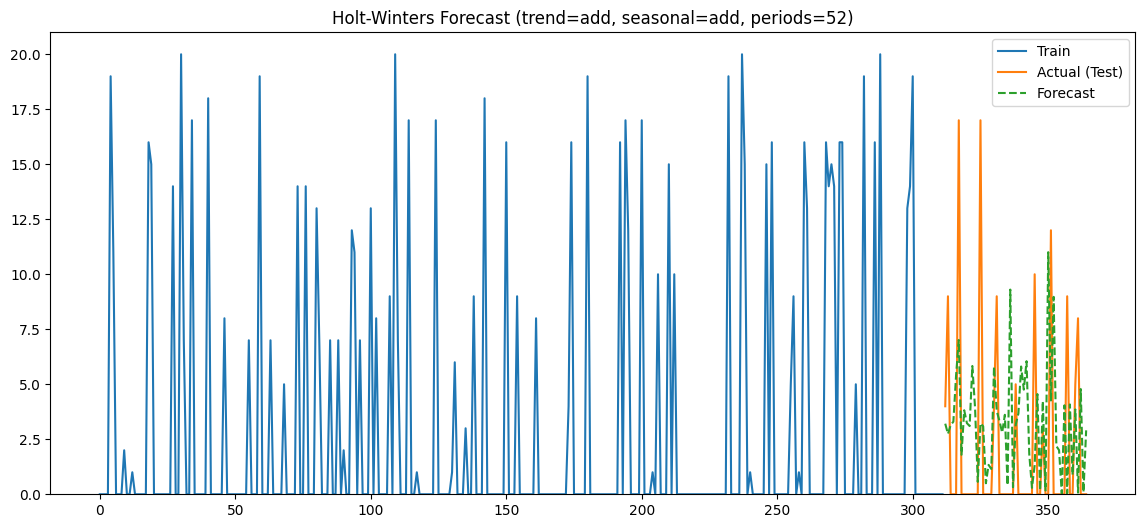

(          date product_id  demand   forecast
 312 2025-11-09    SKU_001       4   3.208523
 313 2025-11-10    SKU_001       9   2.742963
 314 2025-11-11    SKU_001       0   3.148499
 315 2025-11-12    SKU_001       0   3.299398
 316 2025-11-13    SKU_001       0   5.409808
 317 2025-11-14    SKU_001      17   7.014464
 318 2025-11-15    SKU_001       0   1.796934
 319 2025-11-16    SKU_001       0   3.817403
 320 2025-11-17    SKU_001       0   3.232099
 321 2025-11-18    SKU_001       0   3.101575
 322 2025-11-19    SKU_001       0   5.831874
 323 2025-11-20    SKU_001       0   3.936256
 324 2025-11-21    SKU_001       0   0.563530
 325 2025-11-22    SKU_001      17   3.225005
 326 2025-11-23    SKU_001       0   3.089674
 327 2025-11-24    SKU_001       0   0.500905
 328 2025-11-25    SKU_001       0   1.336441
 329 2025-11-26    SKU_001       0   1.149287
 330 2025-11-27    SKU_001       4   5.804712
 331 2025-11-28    SKU_001       9   3.787522
 332 2025-11-29    SKU_001       0

In [ ]:
#  ╔══════════════════════════════════════════════════════════╗
#  ║  CHANGE the values below and re-run this cell            ║
#  ╚══════════════════════════════════════════════════════════╝

holt_winters_forecast(
    intermittent_demand,      # <-- CHANGE to seasonal_demand or smooth_demand
    trend="add",              # <-- CHANGE to None
    seasonal="add",           # <-- CHANGE to None
    seasonal_periods=52,      # <-- CHANGE to 7 or 30
)

**What did you learn?** Holt-Winters works best when there is a genuine seasonal pattern in the data and you set `seasonal_periods` to match it. On data with no seasonality, turning it off (`seasonal=None`) often gives better results.

---
### 4F: ARIMA

**The idea:** Combine three components to forecast:

| Letter | Stands for | What it does |
|--------|-----------|-------------|
| **AR** (p) | AutoRegressive | Uses the last *p* actual values to predict the next one |
| **I** (d) | Integrated | Differences the data *d* times to remove trends |
| **MA** (q) | Moving Average | Uses the last *q* forecast errors to correct the prediction |

You specify the model as `ARIMA(p, d, q)`. For example, `ARIMA(1, 0, 1)` uses 1 past value and 1 past error, with no differencing.

**Note:** An `AR(1)` model (i.e. `ARIMA(1,0,0)`) often behaves very similarly to the Naive forecast — it learns that the best predictor of tomorrow is... today.

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  FUNCTION DEFINITION — Just run this cell, do not change ║
# ╚══════════════════════════════════════════════════════════╝

def arima_forecast(df, order=(1, 0, 1), plot=True):
    train = df.iloc[:-TEST_SIZE].copy()
    test = df.iloc[-TEST_SIZE:].copy()
    history = train["demand"].tolist()
    predictions = []

    for t in range(len(test)):
        try:
            model = ARIMA(history, order=order)
            model_fit = model.fit()
            yhat = model_fit.forecast(1)[0]
        except Exception:
            yhat = np.mean(history[-7:])  # Fallback if model fails
        predictions.append(yhat)
        history.append(test["demand"].iloc[t])

    test = test.copy()
    test["forecast"] = predictions

    mae = mean_absolute_error(test["demand"], test["forecast"])
    rmse = np.sqrt(mean_squared_error(test["demand"], test["forecast"]))
    mape = mean_absolute_percentage_error(test["demand"], test["forecast"])

    metrics = {"MAE": round(mae, 2), "RMSE": round(rmse, 2), "MAPE": round(mape, 4)}
    print(f"MAE: {metrics['MAE']}  |  RMSE: {metrics['RMSE']}  |  MAPE: {metrics['MAPE']}")

    if plot:
        plt.figure(figsize=(14, 6))
        plt.plot(train.index, train["demand"], label="Train")
        plt.plot(test.index, test["demand"], label="Actual (Test)")
        plt.plot(test.index, test["forecast"], label=f"Forecast ARIMA{order}", linestyle="--")
        plt.ylim(bottom=0)
        plt.legend()
        plt.title(f"ARIMA{order} Forecast")
        plt.show()

    return test, metrics

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  RUN FORECAST — Just run this cell, do not change         ║
# ╚══════════════════════════════════════════════════════════╝

arima_test, arima_metrics = arima_forecast(intermittent_demand, order=(1, 0, 1))

### Try It!

**Note: this cell takes 10-20 seconds to run — just wait for it to finish.**

In the cell below, change the three numbers in `order=(p, d, q)` and re-run. Try these combinations:

- `order=(1, 0, 0)` — AR(1) only: tomorrow depends on today. Very similar to Naive.
- `order=(0, 0, 1)` — MA(1) only: tomorrow depends on today's forecast error.
- `order=(2, 1, 1)` — Uses 2 past values, differences once, 1 error term. A common general-purpose setting.
- `order=(5, 1, 0)` — Looks back 5 days with differencing. Good for short-term patterns.

You can also change the **dataset**!

**What to look for:** Do the error metrics improve or get worse? Is there a single best combination?

MAE: 3.63  |  RMSE: 4.42  |  MAPE: 1.0047319633531908e+16


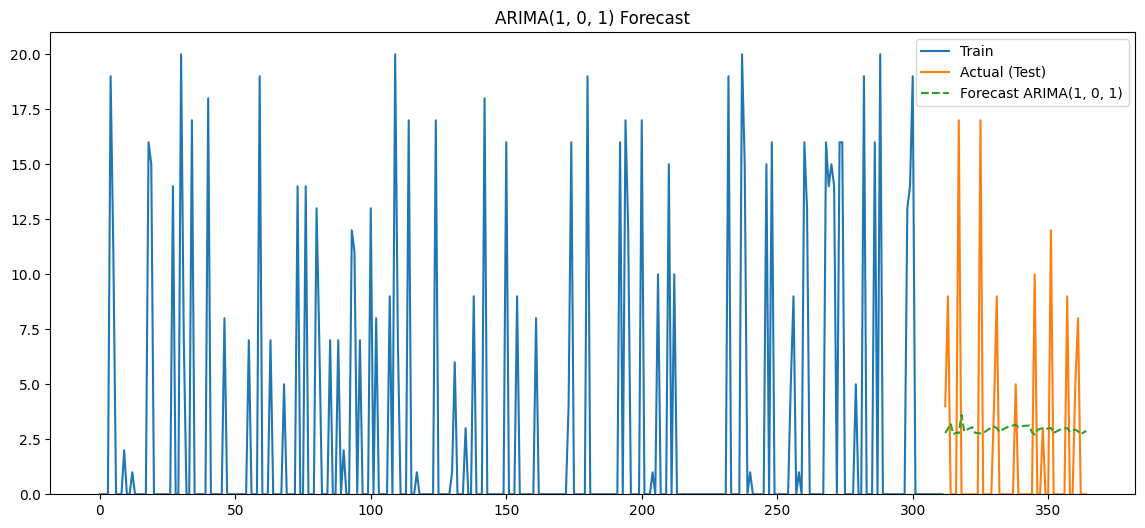

(          date product_id  demand  forecast
 312 2025-11-09    SKU_001       4  2.782298
 313 2025-11-10    SKU_001       9  2.980513
 314 2025-11-11    SKU_001       0  3.213916
 315 2025-11-12    SKU_001       0  2.728523
 316 2025-11-13    SKU_001       0  2.801170
 317 2025-11-14    SKU_001      17  2.775085
 318 2025-11-15    SKU_001       0  3.609574
 319 2025-11-16    SKU_001       0  2.853185
 320 2025-11-17    SKU_001       0  2.933083
 321 2025-11-18    SKU_001       0  2.998594
 322 2025-11-19    SKU_001       0  3.051788
 323 2025-11-20    SKU_001       0  2.789557
 324 2025-11-21    SKU_001       0  2.779358
 325 2025-11-22    SKU_001      17  2.767036
 326 2025-11-23    SKU_001       0  2.775054
 327 2025-11-24    SKU_001       0  2.870344
 328 2025-11-25    SKU_001       0  2.953409
 329 2025-11-26    SKU_001       0  3.021099
 330 2025-11-27    SKU_001       4  3.073322
 331 2025-11-28    SKU_001       9  3.014034
 332 2025-11-29    SKU_001       0  2.833636
 333 2025-

In [ ]:
#  ╔══════════════════════════════════════════════════════════╗
#  ║  CHANGE the values below and re-run this cell            ║
#  ╚══════════════════════════════════════════════════════════╝

arima_forecast(
    intermittent_demand,  # <-- CHANGE to seasonal_demand or smooth_demand
    order=(1, 0, 1),      # <-- CHANGE the three numbers (p, d, q)
)

**What did you learn?** ARIMA is flexible but requires choosing the right (p, d, q) for your data. An AR(1) model often behaves similarly to Naive — it predicts "tomorrow ≈ today". In practice, data scientists use tools like **auto-ARIMA** to search for the best order automatically.

---
## Section 5: The Grand Comparison — All Methods × All Scenarios

Now we run **every method** against **every demand scenario** and compare the results in one table.

The goal: discover which methods work best for which types of demand — and prove that **no single method wins everywhere**.

**This next cell runs 15 forecasts (5 methods × 3 datasets). It will take 2-3 minutes — don't worry, just wait. You will see progress updates as it runs.**

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  COMPARISON — Just run this cell, do not change           ║
# ║  (This takes 2-3 minutes — progress shown below)          ║
# ╚══════════════════════════════════════════════════════════╝

# Run all 5 methods on all 3 scenarios and collect results
scenarios = {
    "Intermittent": intermittent_demand,
    "Seasonal": seasonal_demand,
    "Smooth": smooth_demand,
}

methods = {
    "Naive": lambda df: naive_forecast(df, plot=False),
    "Moving Avg (k=7)": lambda df: moving_average_forecast(df, window=7, plot=False),
    "Exp Smoothing (α=0.3)": lambda df: exp_smoothing_forecast(df, alpha=0.3, plot=False),
    "Holt-Winters": lambda df: holt_winters_forecast(df, plot=False),
    "ARIMA(1,0,1)": lambda df: arima_forecast(df, order=(1, 0, 1), plot=False),
}

all_results = []
total = len(scenarios) * len(methods)
count = 0

for scenario_name, data in scenarios.items():
    for method_name, method_fn in methods.items():
        count += 1
        print(f"Running {method_name} on {scenario_name}... ({count}/{total})")
        _, metrics = method_fn(data)
        all_results.append({
            "Scenario": scenario_name,
            "Method": method_name,
            **metrics,
        })

results_df = pd.DataFrame(all_results)
print("\nDone! Here are all the results:\n")
print(results_df.to_string(index=False))

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  PLOT — Just run this cell, do not change anything        ║
# ╚══════════════════════════════════════════════════════════╝

# Heatmaps: which method wins on which scenario?
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric in zip(axes, ["MAE", "RMSE"]):
    pivot = results_df.pivot(index="Scenario", columns="Method", values=metric)
    # Reorder columns by method complexity
    col_order = [c for c in ["Naive", "Moving Avg (k=7)", "Exp Smoothing (α=0.3)", "Holt-Winters", "ARIMA(1,0,1)"] if c in pivot.columns]
    pivot = pivot[col_order]
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax, linewidths=0.5)
    ax.set_title(f"{metric} by Method and Scenario\n(lower = better)")
    ax.set_ylabel("")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

### Questions to Consider

Look at the heatmaps above and try to answer these questions:

1. Which method had the **lowest MAE** on intermittent demand?
2. Which method had the **lowest MAE** on seasonal demand?
3. Are they the **same method**? Why or why not?
4. Why is **MAPE extremely large** for intermittent demand? *(Hint: what happens when actual demand is 0 and you divide by it?)*
5. Did any "simple" method beat a "complex" one on any scenario?

### Try It!

In the cell below, you can pick **one dataset** and run all 5 methods on it side by side with plots. Change the dataset name and re-run.

**What to look for:** Which method's plot tracks the actual test data best? Does the "best looking" plot always have the best MAE?

NAIVE
MAE: 0.87  |  RMSE: 1.52  |  MAPE: 0.0315


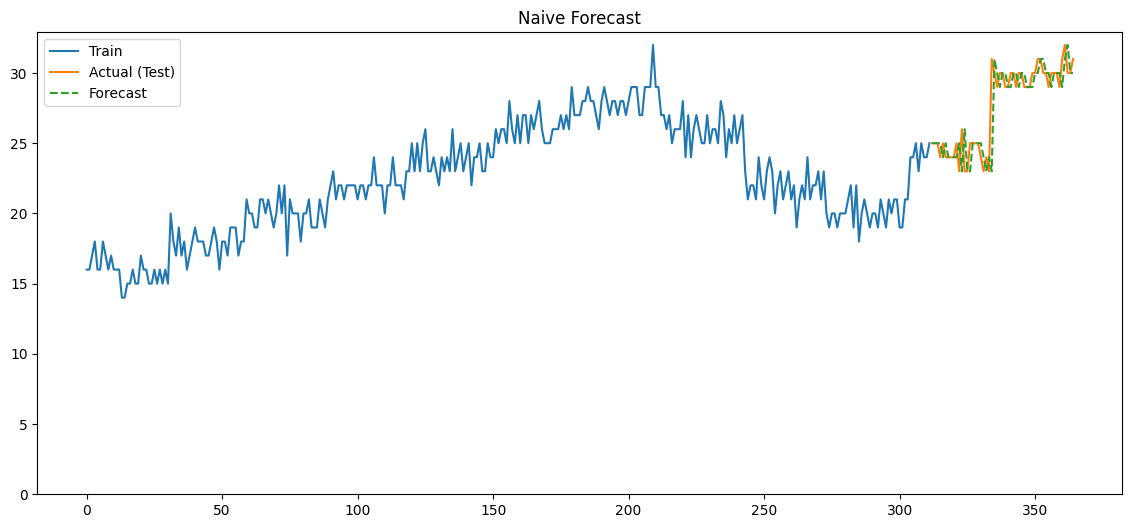


MOVING AVERAGE (window=7)
MAE: 1.06  |  RMSE: 1.62  |  MAPE: 0.0381


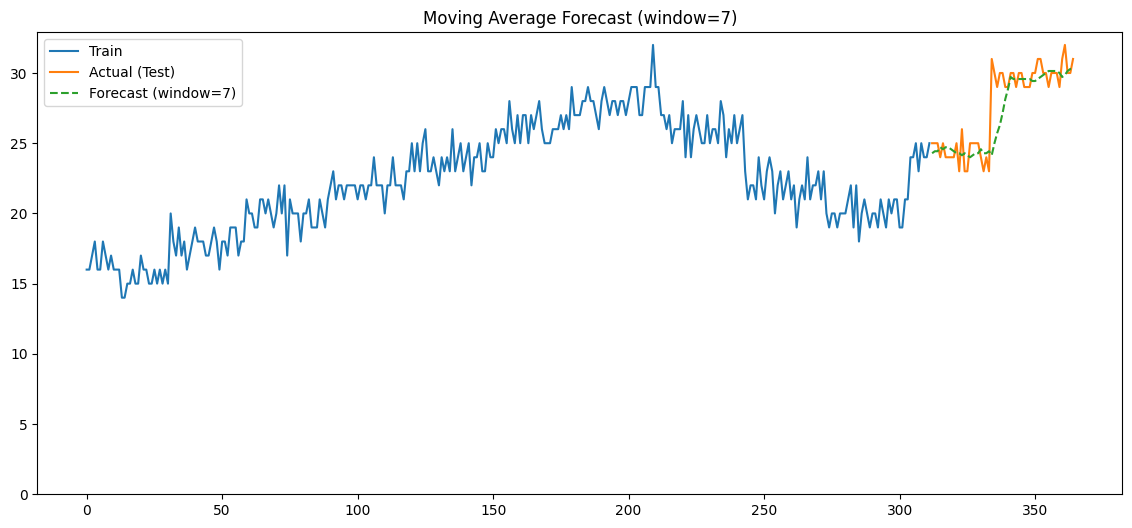


EXPONENTIAL SMOOTHING (alpha=0.3)
MAE: 0.98  |  RMSE: 1.49  |  MAPE: 0.0353


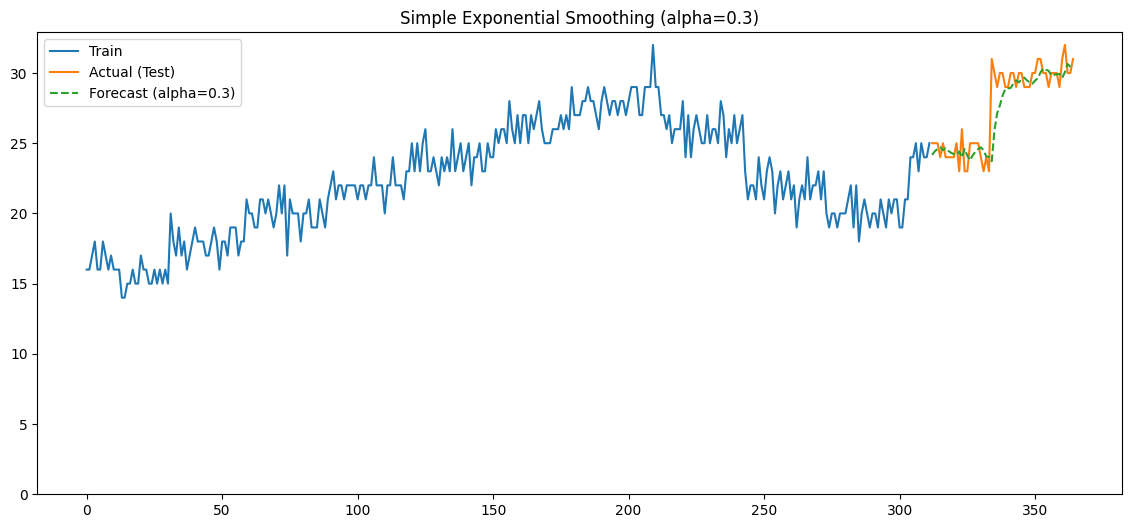


HOLT-WINTERS
MAE: 1.13  |  RMSE: 1.69  |  MAPE: 0.0408


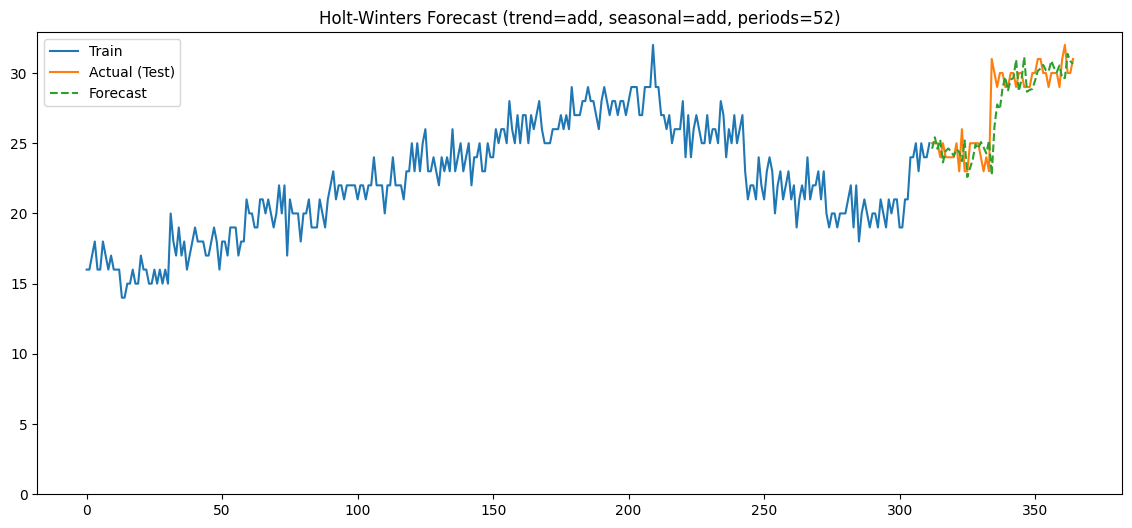


ARIMA(1,0,1)
MAE: 0.97  |  RMSE: 1.47  |  MAPE: 0.0347


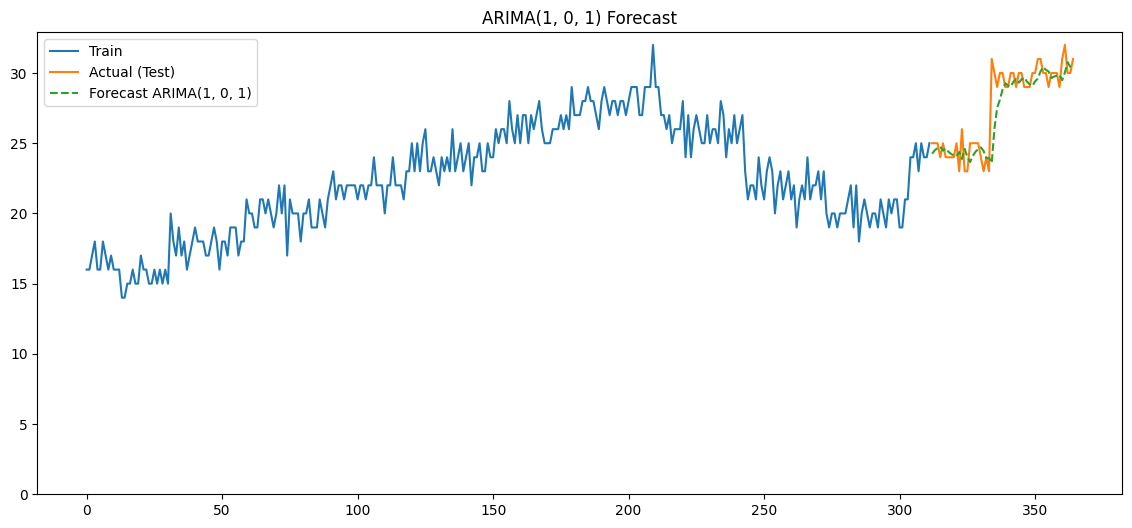

(          date product_id  demand   forecast
 312 2025-11-09    SKU_001      25  24.254513
 313 2025-11-10    SKU_001      25  24.496588
 314 2025-11-11    SKU_001      25  24.653119
 315 2025-11-12    SKU_001      24  24.754005
 316 2025-11-13    SKU_001      25  24.469035
 317 2025-11-14    SKU_001      24  24.633915
 318 2025-11-15    SKU_001      24  24.392523
 319 2025-11-16    SKU_001      24  24.236101
 320 2025-11-17    SKU_001      24  24.134836
 321 2025-11-18    SKU_001      25  24.069292
 322 2025-11-19    SKU_001      23  24.374982
 323 2025-11-20    SKU_001      26  23.878227
 324 2025-11-21    SKU_001      23  24.593884
 325 2025-11-22    SKU_001      23  24.026285
 326 2025-11-23    SKU_001      25  23.655982
 327 2025-11-24    SKU_001      25  24.100755
 328 2025-11-25    SKU_001      25  24.389906
 329 2025-11-26    SKU_001      25  24.578480
 330 2025-11-27    SKU_001      24  24.704633
 331 2025-11-28    SKU_001      23  24.443242
 332 2025-11-29    SKU_001      24

In [ ]:
#  ╔══════════════════════════════════════════════════════════╗
#  ║  CHANGE the dataset below and re-run this cell            ║
#  ║  Options: intermittent_demand, seasonal_demand,            ║
#  ║           smooth_demand                                    ║
#  ╚══════════════════════════════════════════════════════════╝

data = seasonal_demand  # <-- CHANGE THIS

print("=" * 60)
print("NAIVE")
print("=" * 60)
naive_forecast(data)

print("\n" + "=" * 60)
print("MOVING AVERAGE (window=7)")
print("=" * 60)
moving_average_forecast(data, window=7)

print("\n" + "=" * 60)
print("EXPONENTIAL SMOOTHING (alpha=0.3)")
print("=" * 60)
exp_smoothing_forecast(data, alpha=0.3)

print("\n" + "=" * 60)
print("HOLT-WINTERS")
print("=" * 60)
holt_winters_forecast(data)

print("\n" + "=" * 60)
print("ARIMA(1,0,1)")
print("=" * 60)
arima_forecast(data, order=(1, 0, 1))

### Key Takeaway

> **There is no universally best forecasting method.**
>
> The right choice depends on the nature of your data. Understanding your demand pattern is the **first and most important step** in forecasting.

---
## Section 6: Common Pitfalls

Watch out for these common mistakes in forecasting:

1. **Overfitting** — Tuning parameters to perfectly match training data, but failing on new data
2. **Using MAPE on data with zeros** — Dividing by zero gives meaningless results (you saw this with intermittent demand!)
3. **Trusting a visual plot without checking metrics** — The "shifted copy" illusion looked perfect but was useless
4. **Not using walk-forward validation** — If you accidentally use future data to train, your results will be unrealistically good
5. **Applying seasonal methods to non-seasonal data** — Holt-Winters on intermittent demand struggled because there was no pattern to learn

### Overfitting in Action

Let's see this with a concrete example. We will try **every possible window size** (1 to 60) for the Moving Average on smooth demand, and compare:
- **Training error** — how well the model fits the data it has already seen
- **Test error** — how well it predicts data it has never seen

If overfitting occurs, training error will keep improving but test error will get worse.

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  OVERFITTING DEMO — Just run this cell, do not change     ║
# ╚══════════════════════════════════════════════════════════╝

# Sweep window sizes from 1 to 60 and record train + test MAE
train_maes = []
test_maes = []
windows = range(1, 61)

train_data = smooth_demand.iloc[:-TEST_SIZE]
test_data = smooth_demand.iloc[-TEST_SIZE:]

for w in windows:
    history = train_data["demand"].tolist()

    # Training MAE: how well does the model fit training data?
    train_preds = []
    for i in range(w, len(history)):
        train_preds.append(np.mean(history[i - w : i]))
    train_mae = mean_absolute_error(history[w:], train_preds)

    # Test MAE: how well does it predict unseen data?
    test_history = history[:]
    test_preds = []
    for t in range(len(test_data)):
        yhat = np.mean(test_history[-w:])
        test_preds.append(yhat)
        test_history.append(test_data["demand"].iloc[t])
    test_mae = mean_absolute_error(test_data["demand"], test_preds)

    train_maes.append(train_mae)
    test_maes.append(test_mae)

plt.figure(figsize=(12, 6))
plt.plot(list(windows), train_maes, label="Training MAE", linewidth=2)
plt.plot(list(windows), test_maes, label="Test MAE", linewidth=2)
plt.xlabel("Window Size")
plt.ylabel("MAE (lower is better)")
plt.title("Overfitting Demo: Training Error vs Test Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_window = list(windows)[np.argmin(test_maes)]
print(f"Best window for TEST data: {best_window} (Test MAE = {min(test_maes):.2f})")
print(f"Window=1 (Naive) TEST MAE: {test_maes[0]:.2f}")

**What happened?**

- The **smallest window (1 = Naive)** has low training error because it perfectly echoes the data — but it does not have the lowest test error.
- The **best test performance** comes from a moderate window size.
- This is **overfitting**: a model that memorises the past does not necessarily predict the future best.

The same principle applies to all model parameters (alpha, ARIMA order, etc.) — always evaluate on **unseen test data**, not training data.

---
## Summary

Here is what you have learned in this workshop:

1. **Always test on unseen data** — Use train/test splits and walk-forward validation
2. **No single method is best for all scenarios** — Intermittent, seasonal, and smooth data each favour different approaches
3. **Simple methods are often surprisingly competitive** — Don't assume complex = better
4. **Beware the shifted-copy illusion** — A forecast that hugs the actuals may just be echoing yesterday
5. **Match your method to your data** — Understand the demand pattern before choosing a model
6. **Watch out for overfitting** — The best training performance does not mean the best test performance

### What's Next?

If you want to go further, look into:
- **Auto-ARIMA** — Automatically finds the best (p, d, q) for your data
- **Prophet** (by Meta) — Handles seasonality, holidays, and trend changes
- **Machine Learning approaches** — XGBoost, LightGBM, and neural networks for forecasting
- **Ensemble methods** — Combining multiple forecasts for better accuracy